<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/clustering_analysis_eda_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GitHub AI Repositories 2026 - Clustering Analysis

**Objective:** Group GitHub AI repositories into meaningful clusters based on their popularity and activity metrics, using four unsupervised clustering algorithms — **K-Means, Agglomerative Clustering, DBSCAN, and HDBSCAN**.

**Dataset:** `github_ai_repos_2026.csv` — 2,853 GitHub repositories related to AI, with metrics such as stars, forks, watchers, open issues, and repository size.

## 1. Import Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import hdbscan

# Evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score


## 2. Load the Dataset

In [ ]:
# Load the dataset
df = pd.read_csv("github_ai_repos_2026.csv")
df.head()

,full_name,name,owner,description,stars,forks,watchers,open_issues,language,license,...,size_kb,default_branch,is_fork,archived,has_wiki,has_pages,contributors,commits_last_4w,commits_last_52w,html_url
0,tensorflow/tensorflow,tensorflow,tensorflow,An Open Source Machine Learning Framework for ...,194766,75283,194766,4455,C++,Apache-2.0,...,1307558,master,False,False,False,False,5053.0,1039.0,13310.0,https://github.com/tensorflow/tensorflow
1,Significant-Gravitas/AutoGPT,AutoGPT,Significant-Gravitas,AutoGPT is the vision of accessible AI for eve...,183489,46223,183489,382,Python,NOASSERTION,...,510366,master,False,False,True,False,812.0,NaN,NaN,https://github.com/Significant-Gravitas/AutoGPT
2,ollama/ollama,ollama,ollama,"Get up and running with Kimi-K2.5, GLM-5, Mini...",169211,15631,169211,2959,Go,MIT,...,78924,main,False,False,False,False,597.0,NaN,NaN,https://github.com/ollama/ollama
3,f/prompts.chat,prompts.chat,f,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",159897,20939,159897,43,HTML,NOASSERTION,...,312378,main,False,False,True,True,963.0,NaN,NaN,https://github.com/f/prompts.chat
4,huggingface/transformers,transformers,huggingface,🤗 Transformers: the model-definition framework...,159495,32895,159495,2352,Python,Apache-2.0,...,466632,main,False,False,True,False,3878.0,318.0,5212.0,https://github.com/huggingface/transformers


| Column | Description |
|---|---|
| `full_name` | The complete name of the GitHub repository. |
| `name` | The short name of the repository. |
| `owner` | The user or organization that owns the repository. |
| `description` | A short description of the repository. |
| `stars` | The number of GitHub stars received by the repository. |
| `forks` | The number of times the repository has been forked. |
| `watchers` | The number of users watching the repository. |
| `open_issues` | The current number of open issues. |
| `language` | The main programming language used. |
| `license` | The license under which the repository is distributed. |
| `topics` | Keywords or topics associated with the repository. |
| `created_at` | The date when the repository was created. |
| `updated_at` | The date when the repository was last updated. |
| `pushed_at` | The date when code was last pushed. |
| `size_kb` | The size of the repository in kilobytes. |
| `default_branch` | The main branch of the repository. |
| `is_fork` | Shows whether the repository is a fork. |
| `archived` | Shows whether the repository is archived. |
| `has_wiki` | Shows whether the repository has a Wiki. |
| `has_pages` | Shows whether GitHub Pages is enabled. |
| `contributors` | The number of people who contributed to the repository. |
| `commits_last_4w` | The number of commits in the last 4 weeks. |
| `commits_last_52w` | The number of commits in the last 52 weeks. |
| `html_url` | The web URL of the GitHub repository. |

**Clustering features:** `stars`, `forks`, `open_issues`, and `size_kb`.

### Why These 4 Features Are Used for Clustering

- **`stars`** – Measures the overall popularity of a repository.
- **`forks`** – Shows how much the repository is reused or developed by others.
- **`open_issues`** – Indicates the level of activity and ongoing work.
- **`size_kb`** – Represents the repository's codebase size and complexity.

These four features provide useful **numeric information about popularity, activity, and repository size**, making them suitable for clustering.

### Check the Dataset Shape and Available Features

In [ ]:
print("Shape:", df.shape)
df.dtypes

Shape: (2853, 24)


full_name               str
name                    str
owner                   str
description             str
stars                 int64
forks                 int64
watchers              int64
open_issues           int64
language                str
license                 str
topics                  str
created_at              str
updated_at              str
pushed_at               str
size_kb               int64
default_branch          str
is_fork                bool
archived               bool
has_wiki               bool
has_pages              bool
contributors        float64
commits_last_4w     float64
commits_last_52w    float64
html_url                str
dtype: object

The dataset has **2,853 repositories** with **24 columns**.

- **Numeric popularity/activity metrics:** stars, forks, open issues, size
- **Text/categorical metadata:** language, license, topics


### Check for Missing Values Before Clustering

In [ ]:
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Missing values (%):")
print(missing_percent)
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values (%):
commits_last_52w    98.63
commits_last_4w     98.63
contributors        82.47
topics              28.64
license             19.98
language            12.30
description          1.02
dtype: float64

Duplicate rows: 0


### Observation

- `contributors`, `commits_last_4w`, and `commits_last_52w` are missing in **over 80% of rows**, so they are not reliable for clustering.
- `language`, `license`, and `topics` have some missing values but are used only for context.
- There are **no duplicate rows**.

## 3. Basic Exploratory Data Analysis

### Check the Spread and Skew of Key Numeric Features

In [ ]:
num_cols = ["stars", "forks", "open_issues", "size_kb"]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
stars,2853.0,6728.892744,15605.033438,52.0,439.0,1280.0,5911.0,194766.0
forks,2853.0,1127.130039,3444.936824,0.0,61.0,198.0,867.0,75283.0
open_issues,2853.0,96.534876,315.402009,0.0,3.0,15.0,59.0,5057.0
size_kb,2853.0,106105.008412,348679.635365,4.0,2151.0,15889.0,75360.0,6595212.0


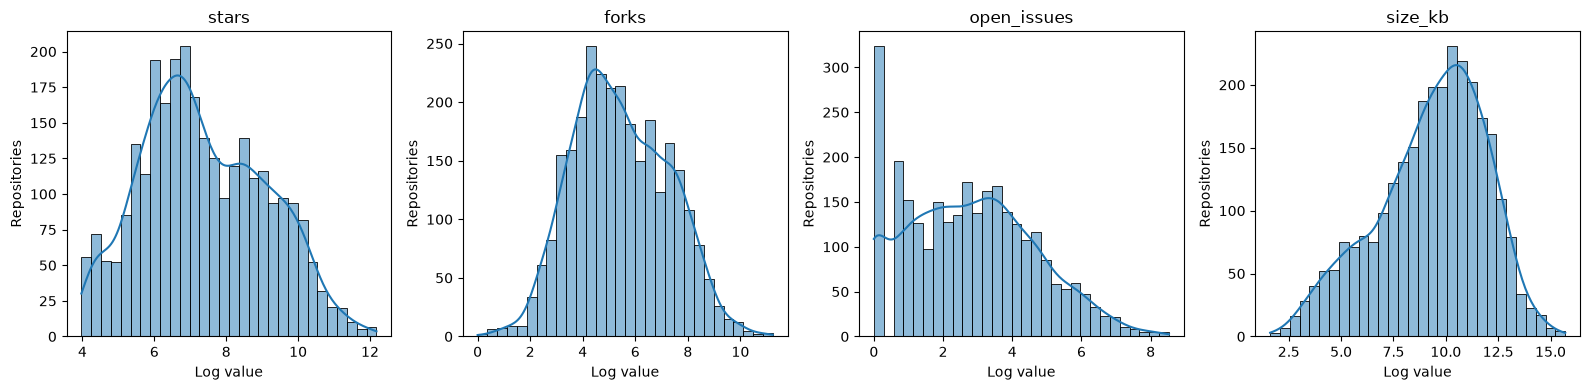

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(num_cols):
    sns.histplot(np.log1p(df[col]), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Log value")
    axes[i].set_ylabel("Repositories")

plt.tight_layout()
plt.show()


- **Observation:** All four features are heavily **right-skewed**.
- Most repositories have small values, while a few highly popular repositories have extremely large values.
- A **log transformation** is needed before clustering because distance-based algorithms are sensitive to skewed and large-scale features.

### Check Which Numeric Features Are Redundant

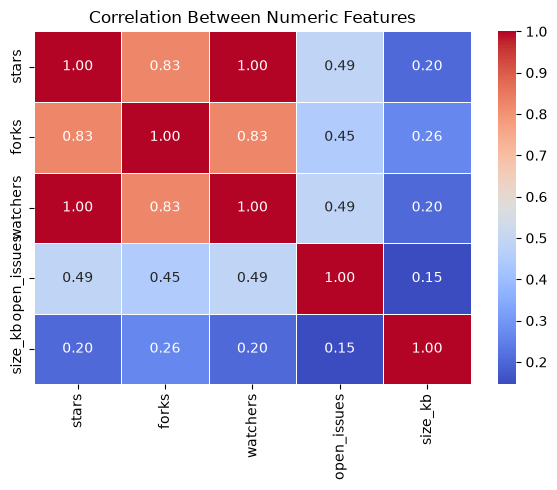

In [ ]:
corr_cols = ["stars", "forks", "watchers", "open_issues", "size_kb"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

- **Most useful features:** `stars`, `forks`, `open_issues`, and `size_kb`.
- `stars` and `watchers` are perfectly correlated (**1.00**), so `watchers` is redundant and excluded.
- `forks` is strongly correlated with `stars` (**~0.83**) but still provides unique information.
- Therefore, clustering uses **`stars`, `forks`, `open_issues`, and `size_kb`**.

## 4. Data Preprocessing for Clustering

### Select the Features Used for Clustering

In [ ]:
features = ["stars", "forks", "open_issues", "size_kb"]
X = df[features].copy()

print("Missing values in selected features:")
print(X.isnull().sum())

Missing values in selected features:
stars          0
forks          0
open_issues    0
size_kb        0
dtype: int64


### Apply Log Transformation to Reduce Skewness

In [ ]:
# log1p = log(1 + x), handles zero values safely
X_log = np.log1p(X)

skew_compare = pd.DataFrame({"Before Log": X.skew(), "After Log": X_log.skew()})
skew_compare.round(3)

,Before Log,After Log
stars,5.687,0.240
forks,10.501,0.173
open_issues,8.244,0.315
size_kb,9.886,-0.475


**Observation:** Skewness drops sharply for every feature after the log transform, making the distributions much closer to symmetric. This is the data we scale and cluster on.

### Scale Numerical Features for Clustering

In [ ]:
# StandardScaler gives every feature mean 0 and standard deviation 1,
# so no single feature (e.g. size_kb) dominates the distance calculation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Mean of each scaled feature:", np.round(X_scaled.mean(axis=0), 2))
print("Std of each scaled feature :", np.round(X_scaled.std(axis=0), 2))

Mean of each scaled feature: [ 0.  0. -0.  0.]
Std of each scaled feature : [1. 1. 1. 1.]


# Clustering Analysis

- We apply four clustering algorithms:
   - **K-Means**
  -  **Agglomerative Clustering**
  -  **DBSCAN**
  -  **HDBSCAN**
- All algorithms use the same **scaled features** for a fair comparison.
- We then compare the results to find the **best clustering method**.

## 5. K-Means Clustering



### Determine a Suitable Number of Clusters for K-Means

In [ ]:
k_values = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))

best_k = list(k_values)[np.argmax(silhouette_list)]
print("Best K based on silhouette score:", best_k)

Best K based on silhouette score: 2


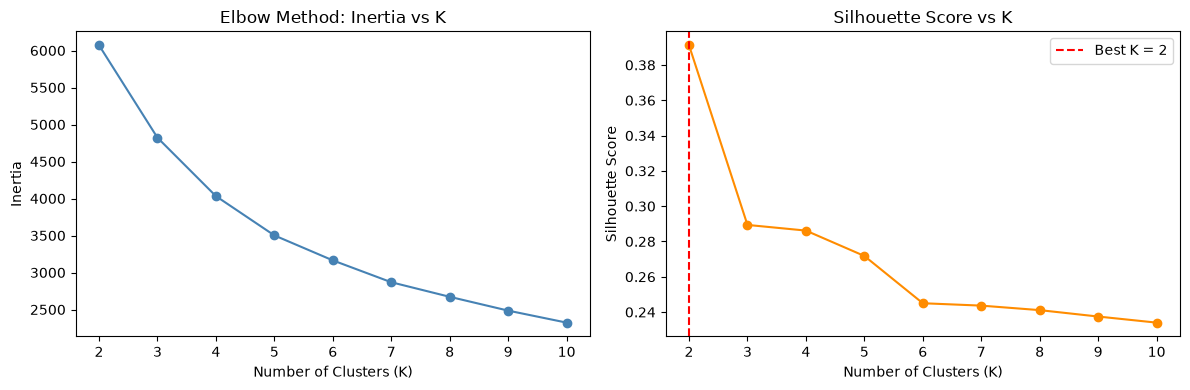

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertia_list, marker="o", color="steelblue")
axes[0].set_title("Elbow Method: Inertia vs K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouette_list, marker="o", color="darkorange")
axes[1].axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.show()

- The elbow curve bends gradually without one sharp **"elbow"**, which is common in real-world data.
- The silhouette score gives a clearer result, peaking at **K = {best_k}**.
- Therefore, **K = {best_k}** is used for K-Means clustering.

### Apply K-Means Clustering to Group Similar Observations

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df["KMeans_Cluster"] = kmeans_labels

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())
print()
print("Silhouette Score    :", round(kmeans_silhouette, 4))
print("Davies-Bouldin Score:", round(kmeans_db, 4))

Cluster sizes:
0    1698
1    1155
Name: count, dtype: int64

Silhouette Score    : 0.3912
Davies-Bouldin Score: 0.9693


### Visualize the K-Means Clusters

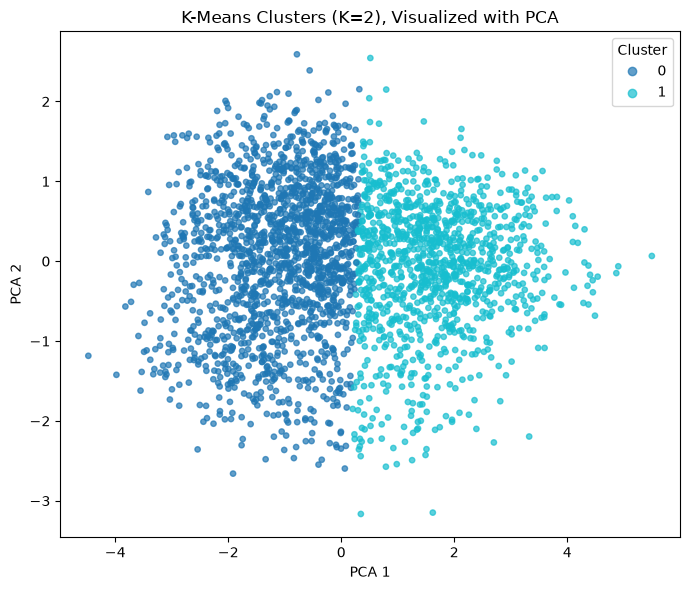

In [ ]:
# Reduce to 2D with PCA purely for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="tab10", s=15, alpha=0.7)
plt.title(f"K-Means Clusters (K={best_k}), Visualized with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()


- **Why is K-Means useful for this dataset?**
- K-Means groups repositories by minimizing their distance from cluster centroids.
- The PCA plot shows clear separation along **PCA 1**, mainly reflecting overall popularity.
- It is **fast, simple, and easy to interpret**.
- However, it assumes roughly round clusters and **cannot identify noise or outliers**.

## 6. Agglomerative Clustering


### Apply Agglomerative Clustering to Build Hierarchical Groups

In [ ]:
# Same K as K-Means, for a fair comparison
agglo = AgglomerativeClustering(n_clusters=best_k)
agglo_labels = agglo.fit_predict(X_scaled)
df["Agglomerative_Cluster"] = agglo_labels

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)

print("Cluster sizes:")
print(pd.Series(agglo_labels).value_counts().sort_index())
print()
print("Silhouette Score    :", round(agglo_silhouette, 4))
print("Davies-Bouldin Score:", round(agglo_db, 4))

Cluster sizes:
0    1986
1     867
Name: count, dtype: int64

Silhouette Score    : 0.3772
Davies-Bouldin Score: 0.938


### Visualize the Agglomerative Clusters

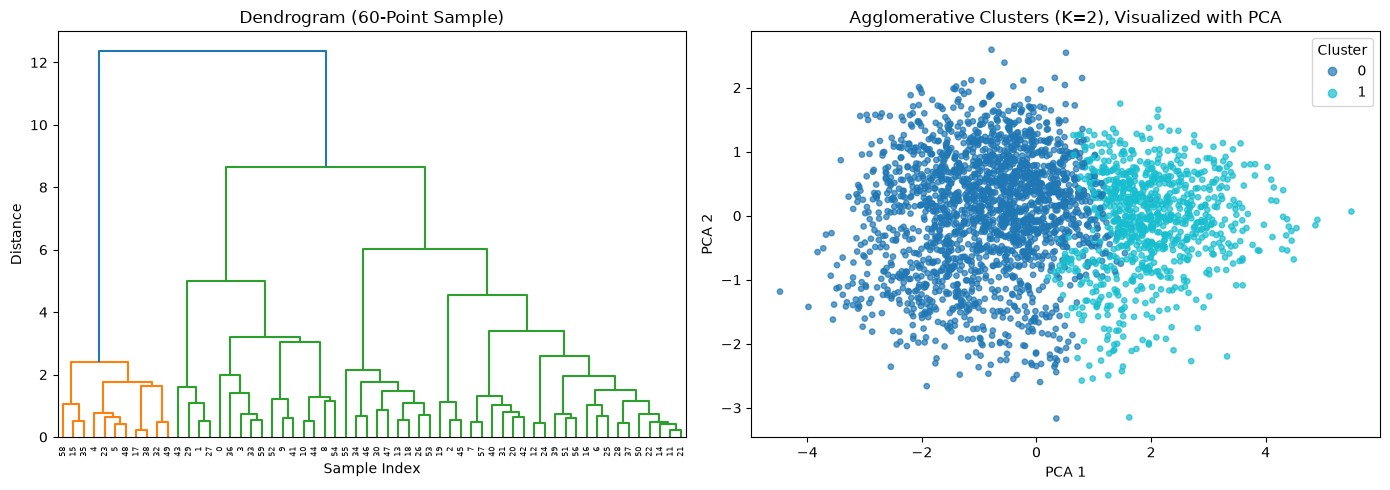

In [ ]:
# A small sample dendrogram shows how points merge step by step
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=60, replace=False)
X_sample = X_scaled[sample_idx]
linked = linkage(X_sample, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dendrogram(linked, ax=axes[0])
axes[0].set_title("Dendrogram (60-Point Sample)")
axes[0].set_xlabel("Sample Index")
axes[0].set_ylabel("Distance")

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap="tab10", s=15, alpha=0.7)
axes[1].set_title(f"Agglomerative Clusters (K={best_k}), Visualized with PCA")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].legend(*scatter.legend_elements(), title="Cluster")

plt.tight_layout()
plt.show()

- **Why is Agglomerative Clustering useful?**
- The dendrogram shows **how clusters form at different levels**, unlike K-Means.
- The PCA results are similar to K-Means, showing both methods agree on the overall structure.
- It can reveal **sub-groups** within larger clusters.
- **Limitation:** It is slower and does not scale well to very large datasets.

## 7. DBSCAN Clustering

- **DBSCAN** groups points in dense regions and labels isolated points as **noise (`-1`)**.
- **`eps`** — maximum distance for points to be considered neighbors.
- **`min_samples`** — minimum points needed to form a dense region.

### Apply DBSCAN to Find Dense Groups Without Choosing the Number of Clusters

In [ ]:
# Try a small set of reasonable eps / min_samples combinations
dbscan_results = []

for eps in [0.3, 0.5, 0.7, 0.9]:
    for min_samples in [5, 10, 15]:
        labels_temp = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise_temp = list(labels_temp).count(-1)
        if n_clusters_temp >= 2:
            sil = silhouette_score(X_scaled, labels_temp)
        else:
            sil = np.nan
        dbscan_results.append([eps, min_samples, n_clusters_temp, n_noise_temp, sil])

dbscan_search = pd.DataFrame(dbscan_results, columns=["eps", "min_samples", "clusters", "noise_points", "silhouette"])
dbscan_search.round(3)

,eps,min_samples,clusters,noise_points,silhouette
0,0.3,5,42,1263,-0.501
1,0.3,10,11,2262,-0.448
2,0.3,15,5,2708,-0.456
3,0.5,5,3,146,0.164
4,0.5,10,1,280,NaN
5,0.5,15,1,488,NaN
6,0.7,5,1,32,NaN
7,0.7,10,2,52,0.235
8,0.7,15,1,75,NaN
9,0.9,5,1,8,NaN


- **Observation:** A very small `eps` creates many tiny clusters and high noise.
- A very large `eps` merges most points into one cluster.
- We choose the settings that give **meaningful clusters, low noise, and a good silhouette score**.

In [ ]:
dbscan = DBSCAN(eps=0.7, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

if n_clusters_dbscan >= 2:
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_db = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
else:
    dbscan_silhouette, dbscan_db = np.nan, np.nan

print("Clusters found :", n_clusters_dbscan)
print("Noise points   :", n_noise_dbscan, f"({n_noise_dbscan / len(df) * 100:.1f}%)")
print("Silhouette Score    :", round(dbscan_silhouette, 4))
print("Davies-Bouldin Score:", round(dbscan_db, 4))

Clusters found : 2
Noise points   : 52 (1.8%)
Silhouette Score    : 0.3981
Davies-Bouldin Score: 0.512


### Visualize DBSCAN Clusters and Noise Points

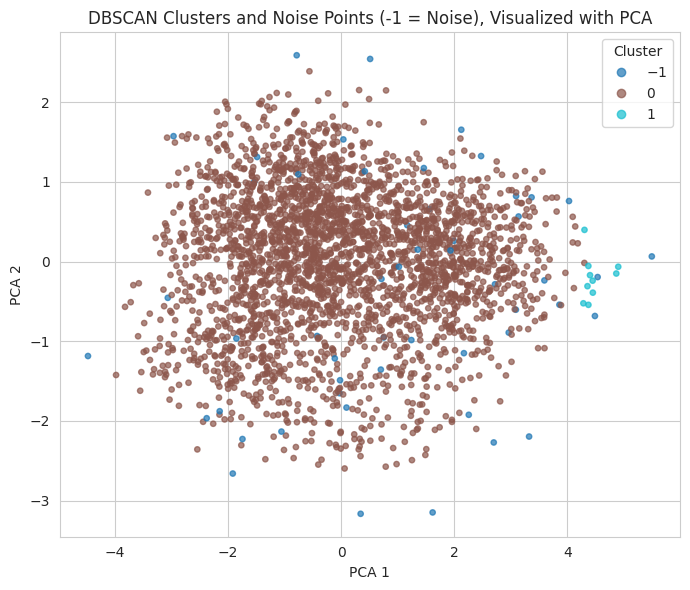

In [ ]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="tab10", s=15, alpha=0.7)
plt.title("DBSCAN Clusters and Noise Points (-1 = Noise), Visualized with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

### Observation: How Does DBSCAN Handle Dense Groups and Outliers?

- **No need to choose K:** DBSCAN automatically finds the number of clusters based on data density using `eps` and `min_samples`.
- **Noise (`-1`):** Represents repositories in low-density regions that do not closely fit either cluster.
- These points may be **unusual or transitional repositories**, rather than errors.
- DBSCAN works well for **irregular clusters and outlier detection**, but may struggle with clusters having different densities.

## 8. HDBSCAN Clustering

- **HDBSCAN** extends DBSCAN by handling clusters with **different densities**.
- Unlike DBSCAN, it does not rely on one fixed `eps`.
- Its main parameter is **`min_cluster_size`**, which controls the minimum size of a cluster.

### Apply HDBSCAN to Detect Clusters with Different Densities

In [ ]:
hdb = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
hdbscan_labels = hdb.fit_predict(X_scaled)
df["HDBSCAN_Cluster"] = hdbscan_labels

n_clusters_hdbscan = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise_hdbscan = list(hdbscan_labels).count(-1)

if n_clusters_hdbscan >= 2:
    mask = hdbscan_labels != -1
    hdbscan_silhouette = silhouette_score(X_scaled[mask], hdbscan_labels[mask])
    hdbscan_db = davies_bouldin_score(X_scaled[mask], hdbscan_labels[mask])
else:
    hdbscan_silhouette, hdbscan_db = np.nan, np.nan

print("Clusters found :", n_clusters_hdbscan)
print("Noise points   :", n_noise_hdbscan, f"({n_noise_hdbscan / len(df) * 100:.1f}%)")
print("Silhouette Score    :", round(hdbscan_silhouette, 4))
print("Davies-Bouldin Score:", round(hdbscan_db, 4))

Clusters found : 2
Noise points   : 1183 (41.5%)
Silhouette Score    : 0.1754
Davies-Bouldin Score: 1.1481


### Visualize HDBSCAN Clusters and Noise

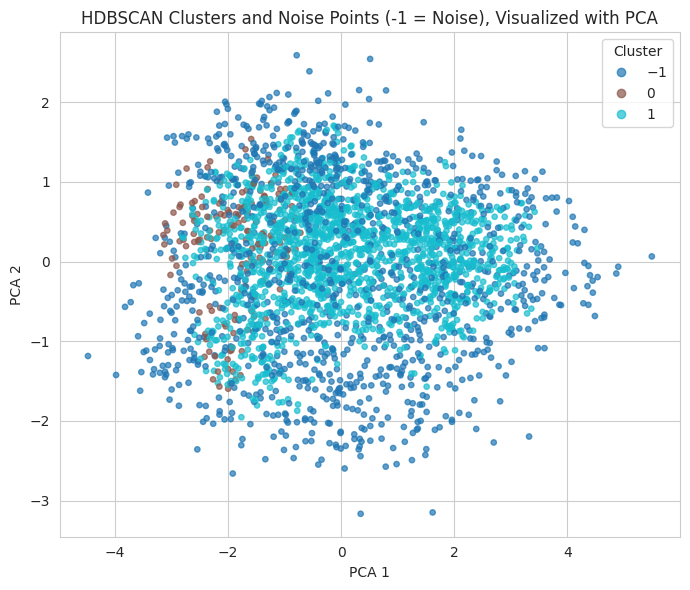

In [ ]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hdbscan_labels, cmap="tab10", s=15, alpha=0.7)
plt.title("HDBSCAN Clusters and Noise Points (-1 = Noise), Visualized with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

### Observation: How Does HDBSCAN Improve on Density-Based Clustering?

- **HDBSCAN vs DBSCAN:** HDBSCAN can handle varying densities, but on this dataset it labeled many more repositories as **noise** than DBSCAN.
- It still found the same **2 broad clusters**, but with much higher noise.
- **Meaningfulness:** HDBSCAN does not outperform the other methods here because the dataset's density changes gradually.
- **Conclusion:** DBSCAN's simpler fixed-density approach works better for this dataset. HDBSCAN may be more useful when clusters have **clearly different densities**.

## 9. Compare K-Means, Agglomerative Clustering, DBSCAN, and HDBSCAN

In [ ]:
comparison_table = pd.DataFrame({
    "Algorithm": ["K-Means", "Agglomerative", "DBSCAN", "HDBSCAN"],
    "Clusters Found": [best_k, best_k, n_clusters_dbscan, n_clusters_hdbscan],
    "Noise Points": [0, 0, n_noise_dbscan, n_noise_hdbscan],
    "Silhouette Score": [
        round(kmeans_silhouette, 3), round(agglo_silhouette, 3),
        round(dbscan_silhouette, 3) if n_clusters_dbscan >= 2 else np.nan,
        round(hdbscan_silhouette, 3) if n_clusters_hdbscan >= 2 else np.nan
    ],
    "Davies-Bouldin Score": [
        round(kmeans_db, 3), round(agglo_db, 3),
        round(dbscan_db, 3) if n_clusters_dbscan >= 2 else np.nan,
        round(hdbscan_db, 3) if n_clusters_hdbscan >= 2 else np.nan
    ],
    "Handles Noise?": ["No", "No", "Yes", "Yes"],
    "Cluster Shape": ["Mostly spherical", "Flexible", "Arbitrary shapes", "Arbitrary shapes"],
    "Main Strength": ["Simple and fast", "Shows hierarchy", "Detects noise", "Handles varying density"],
    "Main Limitation": ["Requires number of clusters", "Slower on large data", "Sensitive to eps/min_samples", "More complex to tune"]
})
comparison_table

,Algorithm,Clusters Found,Noise Points,Silhouette Score,Davies-Bouldin Score,Handles Noise?,Cluster Shape,Main Strength,Main Limitation
0,K-Means,2,0,0.391,0.969,No,Mostly spherical,Simple and fast,Requires number of clusters
1,Agglomerative,2,0,0.377,0.938,No,Flexible,Shows hierarchy,Slower on large data
2,DBSCAN,2,52,0.398,0.512,Yes,Arbitrary shapes,Detects noise,Sensitive to eps/min_samples
3,HDBSCAN,2,1183,0.175,1.148,Yes,Arbitrary shapes,Handles varying density,More complex to tune


### Overall Observation

- **K-Means:** Found 2 meaningful clusters with a silhouette score of **0.391**. Easy to interpret and assigns every point.
- **Agglomerative:** Found the same 2 clusters with a score of **0.377**. Its main advantage is the dendrogram.
- **DBSCAN:** Performed best with **2 clusters**, the highest silhouette score (**0.398**), and only **1.8% noise**.
- **HDBSCAN:** Performed worst, with a silhouette score of **0.175** and about **41% noise**.

**Conclusion:** **DBSCAN is the best choice** because it has the highest silhouette score and very little noise. **K-Means** is a good, simpler alternative, while HDBSCAN is not well suited to this dataset.

## Summary of the Clustering Analysis Notebook

This notebook performs a clustering analysis on GitHub AI repositories using four unsupervised clustering algorithms: K-Means, Agglomerative Clustering, DBSCAN, and HDBSCAN. The objective is to group repositories based on popularity and activity metrics (`stars`, `forks`, `open_issues`, `size_kb`).

### 1. Import Libraries

This section imports all necessary Python libraries for data handling, visualization, preprocessing, clustering, and evaluation.

The code cell `8ae0bfd6` imports the following libraries:
- **`pandas` and `numpy`**: For data manipulation.
- **`matplotlib.pyplot` and `seaborn`**: For data visualization.
- **`StandardScaler` and `PCA` from `sklearn.preprocessing`**: For data scaling and dimensionality reduction.
- **`KMeans`, `DBSCAN`, `AgglomerativeClustering` from `sklearn.cluster`**: The core clustering algorithms.
- **`dendrogram`, `linkage` from `scipy.cluster.hierarchy`**: For visualizing hierarchical clustering.
- **`hdbscan`**: The HDBSCAN clustering algorithm.
- **`silhouette_score`, `davies_bouldin_score` from `sklearn.metrics`**: For evaluating clustering performance.

### 2. Load the Dataset

This section loads the `github_ai_repos_2026.csv` dataset and provides an overview of its structure and content.

The code cell `f1e1a8af` loads the CSV file into a pandas DataFrame named `df` and displays the first 5 rows to give an initial look at the data.

The cell `cae75b0d` prints the shape of the DataFrame (`df.shape`) to show the number of rows and columns, and then displays the data types of each column (`df.dtypes`).

The cell `5841afcf` calculates and prints the percentage of missing values for each column (`isnull().sum() / len(df) * 100`) and also checks for any duplicate rows (`duplicated().sum()`). This helps identify columns with significant missing data that might need to be handled or excluded.

### 3. Basic Exploratory Data Analysis

This section explores the distribution and correlation of the key numeric features chosen for clustering.

The code cell `0d26b635` selects the numerical features (`stars`, `forks`, `open_issues`, `size_kb`) and provides a descriptive summary (`describe().T`) of these columns, showing count, mean, standard deviation, min, max, and quartiles.

The cell `b0a070fb` generates histograms for the log-transformed versions of the selected numerical features. The `np.log1p` function is used to handle zero values safely during log transformation. These plots help visualize the distribution of the features and confirm their right-skewness before and after transformation.

The cell `c930367f` computes and visualizes the correlation matrix for `stars`, `forks`, `watchers`, `open_issues`, and `size_kb` using a heatmap. This helps identify highly correlated features (like `stars` and `watchers`) that might lead to redundancy in the clustering process.

### 4. Data Preprocessing for Clustering

This section prepares the selected features for clustering by applying log transformation and standardization.

The code cell `6002cf6f` selects the final features for clustering (`stars`, `forks`, `open_issues`, `size_kb`) and assigns them to `X`. It also checks for any missing values within these selected features to ensure data integrity before further processing.

The cell `0f99d120` applies a log transformation (`np.log1p`) to the `X` features, creating `X_log`. It then calculates and compares the skewness of the features before and after the log transformation to demonstrate the effectiveness of the transformation in reducing skewness.

The cell `3e113420` initializes and applies `StandardScaler` to `X_log`, resulting in `X_scaled`. This process scales the data to have a mean of 0 and a standard deviation of 1, preventing features with larger magnitudes from dominating the distance calculations in clustering algorithms.

### 5. K-Means Clustering

This section applies K-Means clustering, determines the optimal number of clusters, and evaluates the results.

The code cell `8a17c8fd` iterates through a range of K values (2 to 10) to determine the optimal number of clusters for K-Means. For each K, it performs K-Means clustering, calculates the inertia, and computes the silhouette score. The `best_k` is chosen based on the highest silhouette score.

The cell `f5a0068a` visualizes the results of the elbow method (inertia vs. K) and the silhouette score method (silhouette score vs. K). These plots help in visually identifying the optimal `k`, with a vertical red line indicating the `best_k` found by the silhouette score.

The cell `d5d0fde2` applies K-Means clustering using the `best_k` determined previously. It assigns the resulting cluster labels to a new column `KMeans_Cluster` in the original DataFrame `df`. It then prints the size of each cluster and evaluates the clustering performance using the silhouette score and Davies-Bouldin score.

The cell `af1de5d4` reduces the `X_scaled` data to two dimensions using PCA for visualization purposes. It then creates a scatter plot of the PCA-transformed data, coloring the points according to their K-Means cluster labels. This provides a 2D representation of how well the clusters are separated.

### 6. Agglomerative Clustering

This section applies Agglomerative Clustering and visualizes the hierarchical structure of the clusters.

The code cell `27a5ce47` applies Agglomerative Clustering using the same `best_k` as K-Means for comparison. It adds the cluster labels to the `df` as `Agglomerative_Cluster` and calculates the silhouette and Davies-Bouldin scores for evaluation.

The cell `daa6e8c1` generates a dendrogram using a small sample of the data to illustrate the hierarchical merging of clusters. It also displays a PCA-based scatter plot of the clusters, similar to the K-Means visualization, to show the spatial distribution of the Agglomerative clusters.

### 7. DBSCAN Clustering

This section implements DBSCAN, a density-based clustering algorithm, to identify clusters and noise points.

The code cell `6162b545` performs a parameter search for DBSCAN by iterating through different combinations of `eps` (maximum distance) and `min_samples` (minimum points to form a dense region). For each combination, it calculates the number of clusters, noise points, and the silhouette score, presenting these results in a DataFrame to help choose optimal parameters.

The cell `24fb9633` applies DBSCAN with selected `eps` and `min_samples` values. It assigns the resulting labels to `df['DBSCAN_Cluster']`, calculates the number of clusters and noise points, and evaluates the clustering using silhouette and Davies-Bouldin scores (excluding noise points from the evaluation).

The cell `bb58de5c` visualizes the DBSCAN clusters on a PCA-transformed scatter plot. It shows how DBSCAN identifies dense regions as clusters and marks isolated points as noise (-1).

### 8. HDBSCAN Clustering

This section explores HDBSCAN, an advanced density-based algorithm that handles varying cluster densities.

The code cell `948041e0` applies HDBSCAN with specified `min_cluster_size` and `min_samples`. It adds the cluster labels to `df['HDBSCAN_Cluster']`, calculates the number of clusters and noise points, and evaluates the performance using silhouette and Davies-Bouldin scores.

The cell `98303c6e` visualizes the HDBSCAN clusters on a PCA-transformed scatter plot, similar to DBSCAN. This allows for a comparison of how HDBSCAN's approach to density-based clustering differs and identifies noise.

### 9. Compare K-Means, Agglomerative Clustering, DBSCAN, and HDBSCAN

This final section provides a comparative summary of all four clustering algorithms and their performance.

The code cell `69971908` creates a DataFrame `comparison_table` that summarizes the key characteristics and performance metrics (Clusters Found, Noise Points, Silhouette Score, Davies-Bouldin Score, Handles Noise?, Cluster Shape, Main Strength, Main Limitation) for each of the four clustering algorithms applied in the notebook. This table allows for a direct comparison of the algorithms' effectiveness on this specific dataset.